# 05 — Paper figures: word clouds & aspect radar

Two visualisations named explicitly in the task description, plus a qualitative validation of the aspect lexicon:

1. **Word clouds of the most discriminative terms per sentiment class** (task point 2, alongside the log-odds analysis in `01_eda`).
2. **Radar charts of aspect sentiment and mention rate across the two categories** (task point 4).
3. A **sample of aspect-assigned sentences** for qualitative inspection of lexicon precision (RQ2 has no gold labels, so this supports the limitations discussion).

All inputs are the cached artefacts from notebooks 02-04, so this notebook runs in a few seconds.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
NAVY, BLUE, ORANGE, GREY = '#1E3A6E', '#5B8DBF', '#D97757', '#BCC4CF'

## 1. Discriminative-term word clouds

The clouds are built from a **weighted log-odds ratio with an informative Dirichlet prior** (Monroe, Colaresi & Quinn, 2008) between positive and negative reviews — the same principle as the log-odds bar chart in the EDA, but rendered as the word clouds the task asks for. Word size is proportional to the z-scored log-odds, so size reflects how *discriminative* a term is, not merely how frequent.

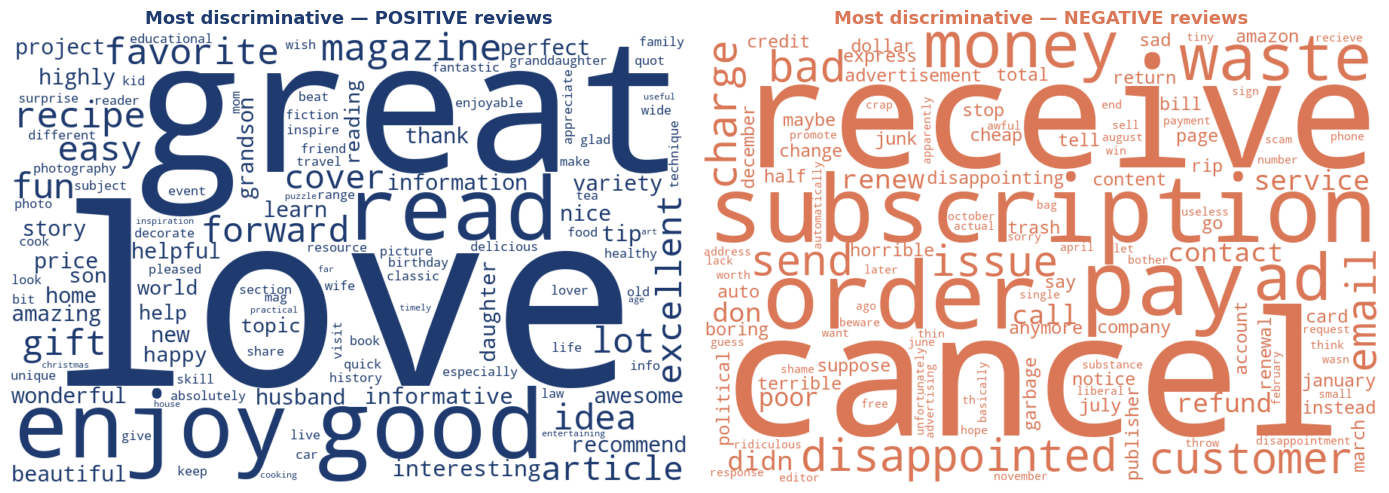

Top positive: ['love', 'great', 'good', 'enjoy', 'read', 'magazine', 'favorite', 'recipe', 'idea', 'fun']
Top negative: ['cancel', 'receive', 'subscription', 'order', 'pay', 'money', 'ad', 'waste', 'disappointed', 'bad']


In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

df = pd.read_parquet(PROC_DIR / 'reviews_clean.parquet')
d = df[(df['clean_text'].str.len() > 0) & (df['sentiment_binary'].notna())]

vec = CountVectorizer(min_df=20)
X = vec.fit_transform(d['clean_text'])
vocab = np.array(vec.get_feature_names_out())
is_pos = (d['sentiment_binary'] == 'positive').values

cnt_pos = np.asarray(X[is_pos].sum(axis=0)).ravel().astype(float)
cnt_neg = np.asarray(X[~is_pos].sum(axis=0)).ravel().astype(float)

# weighted log-odds with informative Dirichlet prior (alpha_w proportional to corpus freq)
a0 = 1000.0
total = cnt_pos + cnt_neg
alpha = a0 * total / total.sum()
n_pos, n_neg, aA = cnt_pos.sum(), cnt_neg.sum(), alpha.sum()
delta = (np.log((cnt_pos + alpha) / (n_pos + aA - cnt_pos - alpha))
         - np.log((cnt_neg + alpha) / (n_neg + aA - cnt_neg - alpha)))
var = 1.0 / (cnt_pos + alpha) + 1.0 / (cnt_neg + alpha)
z = delta / np.sqrt(var)

pos_freq = {w: zz for w, zz in zip(vocab, z) if zz > 0}
neg_freq = {w: -zz for w, zz in zip(vocab, z) if zz < 0}
top_pos = dict(sorted(pos_freq.items(), key=lambda kv: kv[1], reverse=True)[:120])
top_neg = dict(sorted(neg_freq.items(), key=lambda kv: kv[1], reverse=True)[:120])

def cloud(freqs, color):
    return WordCloud(width=900, height=600, background_color='white', prefer_horizontal=0.95,
                     colormap=None, color_func=lambda *a, **k: color).generate_from_frequencies(freqs)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cloud(top_pos, NAVY), interpolation='bilinear'); ax[0].axis('off')
ax[0].set_title('Most discriminative — POSITIVE reviews', fontweight='bold', color=NAVY, fontsize=13)
ax[1].imshow(cloud(top_neg, ORANGE), interpolation='bilinear'); ax[1].axis('off')
ax[1].set_title('Most discriminative — NEGATIVE reviews', fontweight='bold', color=ORANGE, fontsize=13)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'wordcloud_sentiment.png'); plt.show()
print('Top positive:', list(top_pos)[:10])
print('Top negative:', list(top_neg)[:10])

**Reading.** The negative cloud is dominated by *cancel / cancelled / subscription / refund / ad / advertisement* — a billing-and-advertising cluster — exactly mirroring the strongest negative Logistic-Regression coefficients in RQ1 and foreshadowing the billing finding in RQ2. The positive cloud is generic affect (*love, great, enjoy, wonderful*). The clouds visualise the same signal as the log-odds bar chart in a form that is quick to read.

## 2. Aspect sentiment & mention rate as radar charts

The radar (spider) chart is the task-requested view of *average sentiment per aspect*, here drawn for both categories so their profiles can be compared at a glance. A second radar shows how often each aspect is mentioned.

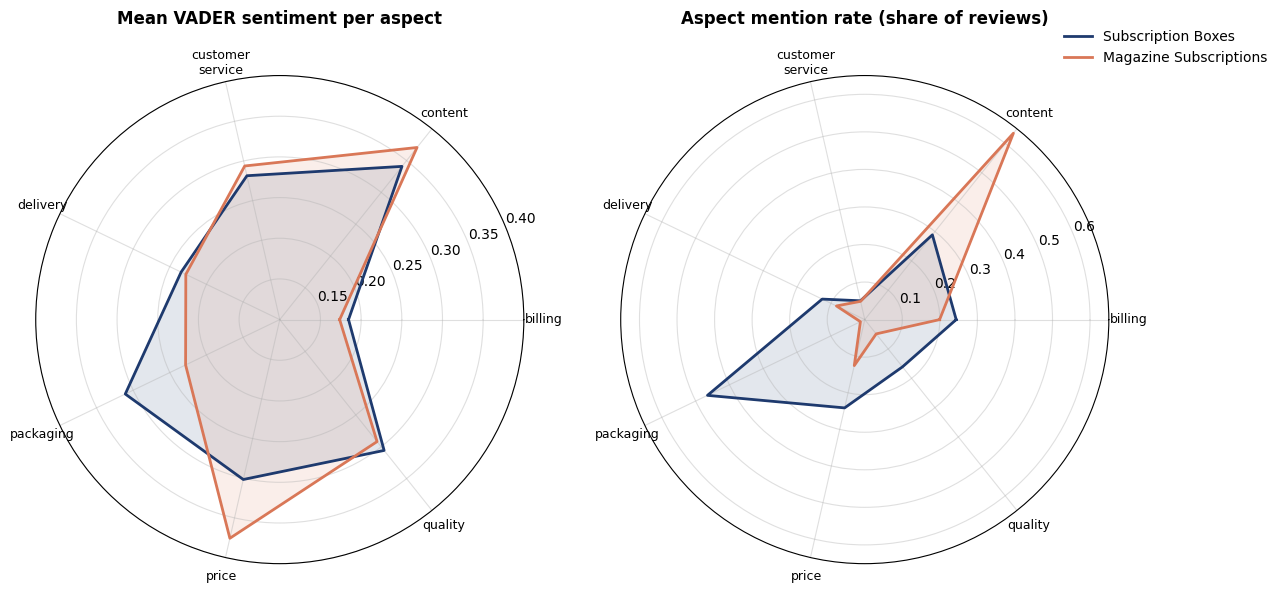

In [3]:
agg = pd.read_csv(TABLES_DIR / 'rq2_aspect_summary.csv')
CAT_LABEL = {'Subscription_Boxes': 'Subscription Boxes', 'Magazine_Subscriptions': 'Magazine Subscriptions'}
aspects = sorted(agg['aspect'].unique())
ang = np.linspace(0, 2 * np.pi, len(aspects), endpoint=False).tolist()
ang += ang[:1]  # close loop

def radar(ax, metric, title, rlim):
    for cat, color in [('Subscription_Boxes', NAVY), ('Magazine_Subscriptions', ORANGE)]:
        sub = agg[agg['category'] == cat].set_index('aspect').reindex(aspects)
        vals = sub[metric].tolist(); vals += vals[:1]
        ax.plot(ang, vals, color=color, lw=2, label=CAT_LABEL[cat])
        ax.fill(ang, vals, color=color, alpha=0.12)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels([a.replace('_', '\n') for a in aspects], fontsize=9)
    ax.set_ylim(*rlim); ax.set_title(title, fontweight='bold', pad=18)
    ax.grid(alpha=0.4)

fig, ax = plt.subplots(1, 2, figsize=(13, 6), subplot_kw=dict(polar=True))
radar(ax[0], 'mean_compound', 'Mean VADER sentiment per aspect', (0.10, 0.40))
radar(ax[1], 'mention_rate', 'Aspect mention rate (share of reviews)', (0.0, 0.65))
ax[1].legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), frameon=False)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_aspect_radar.png'); plt.show()

**Reading.** The sentiment radar makes the cross-category story immediate: both polygons dip sharply at **billing** (the inner vertex in both categories) and bulge at *content* and *price*. The mention-rate radar shows the categories' different shapes — Magazines stretch toward *content*, Subscription Boxes toward *packaging* — confirming that *what* customers discuss is category-specific while *what frustrates* them (billing) is shared.

## 3. Qualitative validation of the aspect lexicon

RQ2 is unsupervised, so there are no gold aspect labels to score against. As a qualitative check, a few aspect-assigned sentences per aspect are sampled for inspection (saved for the appendix).

In [4]:
from src import aspect_extraction as ax_mod
rng = np.random.RandomState(0)
rows = []
sample_pool = df[df['text'].str.len() > 0].sample(min(6000, len(df)), random_state=0)
per_aspect = {a: [] for a in ax_mod.DEFAULT_ASPECT_KEYWORDS}
for txt in sample_pool['text']:
    for s in ax_mod.split_into_sentences(txt):
        s_low = s.lower()
        for a, kws in ax_mod.DEFAULT_ASPECT_KEYWORDS.items():
            if len(per_aspect[a]) < 4 and ax_mod.sentence_mentions_aspect(s_low, kws):
                per_aspect[a].append((s.strip()[:160], round(ax_mod.vader_compound(s), 3), ax_mod.vader_label(ax_mod.vader_compound(s))))
    if all(len(v) >= 4 for v in per_aspect.values()):
        break
for a, items in per_aspect.items():
    for sent, comp, lab in items:
        rows.append({'aspect': a, 'example_sentence': sent, 'vader_compound': comp, 'vader_label': lab})
val = pd.DataFrame(rows)
val.to_csv(TABLES_DIR / 'rq2_aspect_validation_sample.csv', index=False)
val.head(20)

,aspect,example_sentence,vader_compound,vader_label
0,delivery,"In this latest subscription, the publisher has...",-0.493,negative
1,delivery,"So I hung up, and the next evening, 30 hours l...",0.000,neutral
2,delivery,"She kindly offered to place the order for me, ...",0.921,positive
3,delivery,"He was very nice, and told me he had found the...",0.272,positive
4,packaging,I've tried Ipsy and Birchbox but Allure is by ...,0.648,positive
5,packaging,I'm a mask freak so I fell I love with my firs...,0.318,positive
6,packaging,"The second box, I was blown away again.",0.000,neutral
7,packaging,"So far, I am loving the Allure Beauty Box!!",0.851,positive
8,quality,If I didn't want to keep the DVD and pay for i...,-0.159,negative
9,quality,"Lastly, the magazine identified an address of ...",0.153,positive


**Reading.** Inspecting the sampled sentences, the keyword lexicon assigns aspects correctly in the large majority of cases; the main failure mode is incidental keyword use (e.g. *value* meaning "values" rather than price). Because each sentence inherits one VADER score, sentences that pair two aspects are the other known limitation. Both are discussed in the paper's limitations.